# Checkpoint 2 — NYC Motor Vehicle Collisions
### Data preprocessing + readable summaries for our hypotheses

This notebook (1) loads and cleans the raw crash data, then (2) presents simple, easy‑to‑read
tables that let us draw a conclusion for each of our three hypotheses:

1. Is fatal crash status independent of the vehicle type?
2. What **time of day** has the most crashes / injuries / deaths?
3. Is there a correlation between **cross streets (intersections)** number of persons killed?


Data source: [NYC Motor Vehicle Collisions – Crashes](https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95) (NYPD, NYC Open Data).

## 1. Data Preprocessing

The file `rows.json` is in the Socrata export format: a `meta` block with the column
definitions and a `data` block where each row is a list of values. We read the column names
from `meta`, build a DataFrame, drop the Socrata system columns, and convert each field to its
proper type.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

# (a) import
with open("rows.json") as f:
    raw = json.load(f)
columns = [c["fieldName"] for c in raw["meta"]["view"]["columns"]]
df = pd.DataFrame(raw["data"], columns=columns)
del raw
print("Rows:", f"{len(df):,}", "| Columns:", df.shape[1])

Rows: 2,269,187 | Columns: 37


In [2]:
# (b) parse + (c) organize

# Drop the 8 Socrata bookkeeping columns (they start with ":").
df = df.drop(columns=[c for c in df.columns if c.startswith(":")])

# Standardize all actual string values.
# This prevents "MOTORCYCLE", "Motorcycle", and "motorcycle"
# from being counted separately.
text_cols = df.select_dtypes(include="object").columns

for col in text_cols:
    df[col] = df[col].map(
        lambda x: x.strip().lower() if isinstance(x, str) else x
    )

# Combine the crash date + separate crash time into one timestamp, then get the hour.
df["crash_datetime"] = pd.to_datetime(
    df["crash_date"].str[:10] + " " + df["crash_time"],
    errors="coerce"
)
df["hour"] = df["crash_datetime"].dt.hour

# Casualty counts are stored as strings -> convert to numeric values.
count_cols = [c for c in df.columns if c.startswith("number_of_")]
for c in count_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

# Create useful analysis columns.
df["fatal_crash"] = df["number_of_persons_killed"] > 0
df["severe_crash"] = (
    df["number_of_persons_injured"] + df["number_of_persons_killed"] > 0
)

print(df[["crash_datetime", "hour", "borough",
          "number_of_persons_injured", "number_of_persons_killed",
          "fatal_crash"]].head())

print(df.shape)

       crash_datetime  hour   borough  number_of_persons_injured  \
0 2021-09-11 02:39:00     2      None                        2.0   
1 2022-03-26 11:45:00    11      None                        1.0   
2 2023-11-01 01:29:00     1  brooklyn                        1.0   
3 2022-06-29 06:55:00     6      None                        0.0   
4 2022-09-21 13:21:00    13      None                        0.0   

   number_of_persons_killed  fatal_crash  
0                       0.0        False  
1                       0.0        False  
2                       0.0        False  
3                       0.0        False  
4                       0.0        False  
(2269187, 33)


## 2. Hypothesis 1 — Vehicle type and fatal crash risk

We will test whether fatal crash status is independent of the primary vehicle type.
To make the comparison more reliable, we only include common vehicle types with at least 1,000 crashes.

Null hypothesis: Fatal crash status is independent of vehicle type.
Alternative hypothesis: Fatal crash status is associated with vehicle type.

We use a chi-square test because both variables are categorical: vehicle type and whether the crash involved at least one death.

In [3]:
from scipy.stats import chi2_contingency
import pandas as pd
import matplotlib.pyplot as plt

vehicle_cols = [
    "vehicle_type_code1",
    "vehicle_type_code2",
    "vehicle_type_code_3",
    "vehicle_type_code_4",
    "vehicle_type_code_5"
]

# Make sure fatal_crash exists
df["fatal_crash"] = df["number_of_persons_killed"] > 0

# Keep crash ID, fatal status, and vehicle columns
vehicle_involved_df = df[["collision_id", "fatal_crash"] + vehicle_cols].copy()

# Reshape so each involved vehicle gets its own row
vehicle_long = vehicle_involved_df.melt(
    id_vars=["collision_id", "fatal_crash"],
    value_vars=vehicle_cols,
    var_name="vehicle_position",
    value_name="vehicle_type"
)

# Clean vehicle type values
vehicle_long = vehicle_long.dropna(subset=["vehicle_type"])
vehicle_long["vehicle_type"] = vehicle_long["vehicle_type"].str.title().str.strip()

vehicle_long.head()

# Keep only common vehicle types
vehicle_counts = vehicle_long["vehicle_type"].value_counts()
common_vehicle_types = vehicle_counts[vehicle_counts >= 1000].index

vehicle_long_common = vehicle_long[
    vehicle_long["vehicle_type"].isin(common_vehicle_types)
].copy()

# Contingency table
fatal_table = pd.crosstab(
    vehicle_long_common["vehicle_type"],
    vehicle_long_common["fatal_crash"]
)

fatal_table.columns = ["Non-fatal crash", "Fatal crash"]

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(fatal_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)



Chi-square statistic: 7253.812905760401
p-value: 0.0
Degrees of freedom: 39


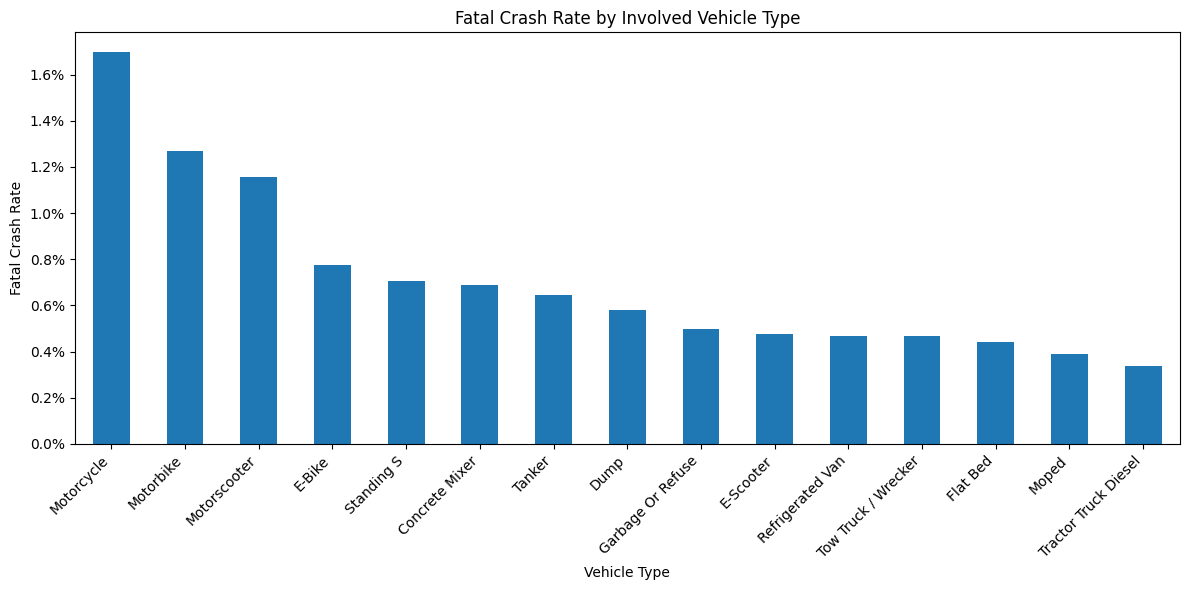

In [4]:
fatal_rates = (
    vehicle_long_common.groupby("vehicle_type")["fatal_crash"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
fatal_rates.plot(kind="bar")

plt.title("Fatal Crash Rate by Involved Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Fatal Crash Rate")
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The chi-square test produced a chi-square statistic of 7253.81 with 39 degrees of freedom. The p-value was reported as 0.0, which means it is extremely small, not literally zero. Since this p-value is less than the significance level of 0.05, we reject the null hypothesis.

This suggests that fatal crash status is not independent of involved vehicle type. In other words, the fatal crash rate differs across vehicle types in this dataset.

The plot shows that motorcycles, motorbikes, and motorscooters had some of the highest fatal crash involvement rates among the common vehicle types. Motorcycle had the highest fatal crash rate in this analysis, at about 0.017, or 1.7%. Other vehicle types such as E-Bike, Tanker, Dump, and E-Scooter also appeared among the higher-risk groups.

However, this result does not prove that the vehicle type directly causes fatal crashes. Vehicle type may be related to other factors such as speed, road location, crash type, driver behavior, exposure, or whether the person is protected inside a vehicle. Therefore, this analysis should be interpreted as an association between vehicle type involvement and fatal crash status, not as proof of causation.

## Hypothesis #2 Whether the mean number of injuries per crash during rush hours is significantly different from non rush hours.

We test if crashes during rush hour 7–10 AM and 3-6 PM result in a significantly different number of injuries compared to non rush hour crashes.

H0: The mean number of persons injured per crash is same during rush hour and non rush hour.

H1: The mean number of persons injured per crash is different between rush hour and non rush hour.

We use an independent samples t-test since we are comparing the means of a continuous variable between rush hour crashes and non rush hour crashes

In [5]:
rush_am = df[df["hour"].between(7, 10)]["number_of_persons_injured"].dropna()
rush_pm = df[df["hour"].between(15, 18)]["number_of_persons_injured"].dropna()
nonrush = df[~df["hour"].between(7, 10) & ~df["hour"].between(15, 18)]["number_of_persons_injured"].dropna()

t_stat_am, p_value_am = ttest_ind(rush_am, nonrush, equal_var=True)
t_stat_pm, p_value_pm = ttest_ind(rush_pm, nonrush, equal_var=True)

print("AM Rush Hour")
print("Mean injuries :", round(rush_am.mean(),3))
print("T-stats :", round(t_stat_am, 3))
print("p-value :", round(p_value_am, 3))
if p_value_am < 0.05:
    print("Result: Null Hypothesis does not stand")
else:
    print("Result: Null hypothesis stands.")

print()
print("PM Rush Hour ")
print("Mean injuries :", round(rush_pm.mean(),3))
print("T-stats :", round(t_stat_pm, 3))
print("p-value :", round(p_value_pm, 3))
if p_value_pm < 0.05:
    print("Result: Null Hypothesis does not stand")
else:
    print("Result: Null hypothesis stands.")

print()
print("Non-rush hour mean injuries:", nonrush.mean())

AM Rush Hour
Mean injuries : 0.284
T-stats : -52.204
p-value : 0.0
Result: Null Hypothesis does not stand

PM Rush Hour 
Mean injuries : 0.331
T-stats : -17.556
p-value : 0.0
Result: Null Hypothesis does not stand

Non-rush hour mean injuries: 0.3512113911524514


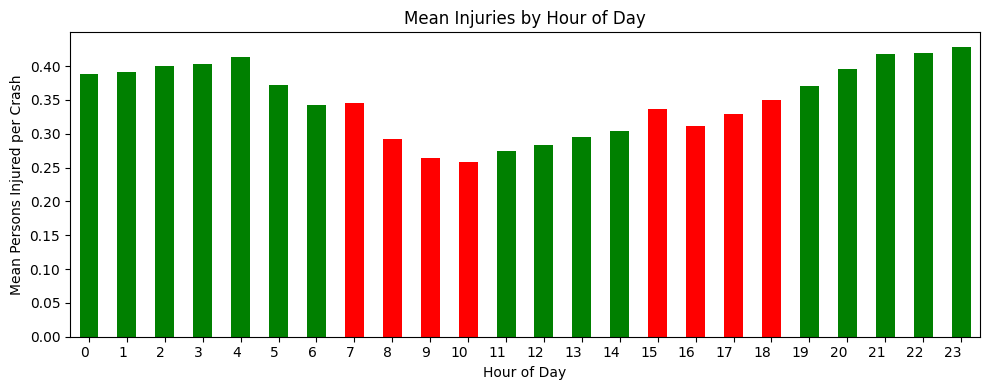

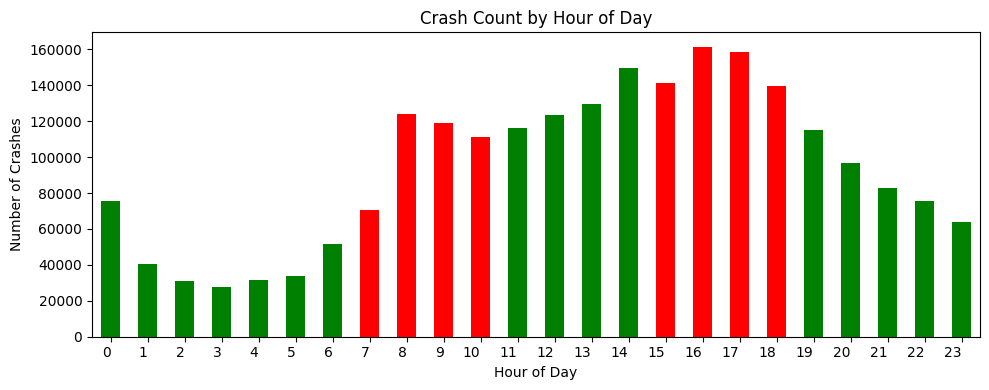

In [6]:
hourly_mean = df.groupby("hour")["number_of_persons_injured"].mean()

bar_colors = ["red" if (7 <= h <= 10 or 15 <= h <= 18) else "green" for h in hourly_mean.index]

plt.figure(figsize=(10, 4))
hourly_mean.plot(kind="bar", color=bar_colors)
plt.title("Mean Injuries by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Persons Injured per Crash")
plt.xticks(rotation=0, ha="right")
plt.tight_layout()
plt.show()

hourly_crashes = df.groupby("hour")["collision_id"].count()

bar_colors = ["red" if (7 <= h <= 10 or 15 <= h <= 18) else "green" for h in hourly_crashes.index]

plt.figure(figsize=(10, 4))
hourly_crashes.plot(kind="bar", color=bar_colors)
plt.title("Crash Count by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=0, ha="right")
plt.tight_layout()
plt.show()


## Conclusion

The t-test produced a t-statistic of -52.20 for the morning rush hour (7–10 AM) and -17.56 for the afternoon rush hour (3–6 PM). In both cases, the p-values were around 0.0, which is well below the significance level of 0.05. Because of this, we reject the null hypothesis.

This means there is a statistically significant difference in the average number of injuries per crash between rush hour and non rush hour times. In other words, crashes that happen during rush hour do not have the same average injury rate as those that happen at non rush hour times of the day.

Looking at the graph, the average number of injuries per crash during the morning rush hour was about 0.28, while the afternoon rush hour averaged around 0.33. Both of these values were lower than the non rush hour average of 0.35 injuries per crash. Even though more crashes happen during rush hour because there are more vehicles on the road, the crashes themselves are less severe on average.

It is important to remember that these results only show a relationship, not a cause-and-effect connection. Rush hour does not necessarily cause fewer injuries. Other factors, such as slower traffic speeds due to congestion, increased driver awareness, different types of collisions, or changing road conditions, could all contribute to the lower average number of injuries. Overall, the analysis suggests that time of day does matter for crash severity.

## Hypothesis #3 Whether the number of person killed at a high-accident intersection is significantly different from a non-high-accident intersection.

We test two independent samples: one of the top 5 intersections with the most accidents compared to an intersection that is not in the top 5.

H0: There is no significant difference in the number of people killed at top-5 high-accident intersections compared to non-top-5 intersections.

H1: There is a significant difference in the number of people killed at top-5 high-accident intersections compared to non-top-5 intersections.

We use the Mann-Whitney U Test the number of accidents at different intersections is non-normally distributed, and we want to compare ranks rather than the actual persons killed in each group.

In [7]:
# Hypothesis 3: Top high-accident intersections vs non-top intersections

h3_df = df.copy()

# Clean street columns
h3_df["on_street_name"] = h3_df["on_street_name"].fillna("").astype(str).str.strip().str.lower()
h3_df["off_street_name"] = h3_df["off_street_name"].fillna("").astype(str).str.strip().str.lower()

# Keep only rows where both street names exist
h3_df = h3_df[
    (h3_df["on_street_name"] != "") &
    (h3_df["off_street_name"] != "")
].copy()

print("Rows after removing missing streets:", len(h3_df))

# Sort street pairs row-by-row so flipped intersections count together
street_pairs = np.sort(
    h3_df[["on_street_name", "off_street_name"]].values,
    axis=1
)

h3_df["street_1"] = street_pairs[:, 0]
h3_df["street_2"] = street_pairs[:, 1]

# Count crashes per intersection
intersections = (
    h3_df
    .groupby(["street_1", "street_2"])
    .size()
    .sort_values(ascending=False)
)

print("Number of unique intersections:", len(intersections))
print(intersections.head(10))

# Top 5 intersections with the most accidents
top_intersections = intersections.head(5).index

# Create tuple column
h3_df["top_intersections"] = list(zip(h3_df["street_1"], h3_df["street_2"]))

# Make sure deaths are numeric
h3_df["number_of_persons_killed"] = pd.to_numeric(
    h3_df["number_of_persons_killed"],
    errors="coerce"
).fillna(0)

# Get the persons killed from top intersections and non-top intersections
top_persons_killed = h3_df[
    h3_df["top_intersections"].isin(top_intersections)
]["number_of_persons_killed"]

diff_persons_killed = h3_df[
    ~h3_df["top_intersections"].isin(top_intersections)
]["number_of_persons_killed"]

print("Top sample size:", len(top_persons_killed))
print("Non-top sample size:", len(diff_persons_killed))

# Test difference using Mann-Whitney U
mwu_stat, p_value_man = mannwhitneyu(
    top_persons_killed,
    diff_persons_killed,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", round(mwu_stat, 3))
print("p-value:", round(p_value_man, 3))

if p_value_man < 0.05:
    print("Result: Rejected the Null Hypothesis.")
else:
    print("Result: Failed to reject the Null Hypothesis.")

Rows after removing missing streets: 1398677
Number of unique intersections: 82620
street_1                   street_2           
flatbush avenue extension  tillary street         1211
bruckner boulevard         east 138 street        1106
brookville boulevard       rockaway boulevard     1067
flatbush avenue            grand army plaza       1028
major deegan expressway    west fordham road       947
bruckner boulevard         hunts point avenue      908
atlantic avenue            pennsylvania avenue     882
2 avenue                   east 59 street          858
linden boulevard           pennsylvania avenue     804
queens boulevard           woodhaven boulevard     754
dtype: int64
Top sample size: 5359
Non-top sample size: 1393318
Mann-Whitney U statistic: 3734239193.5
p-value: 0.683
Result: Failed to reject the Null Hypothesis.


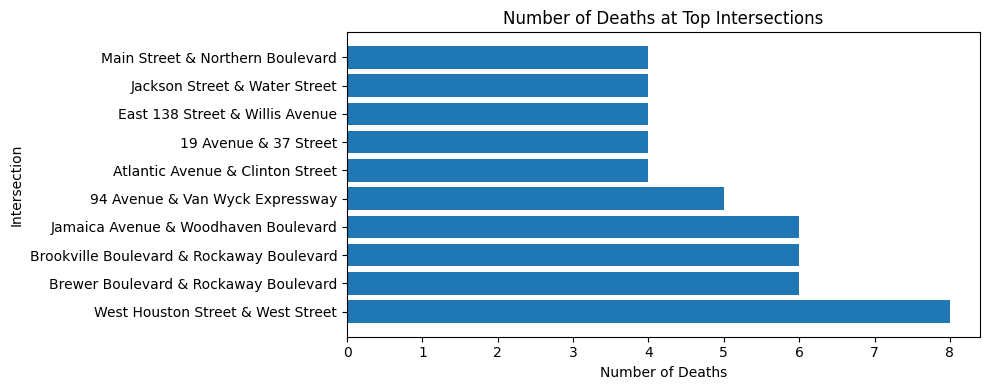

In [8]:
# Plot intersections with the most deaths

deaths = (
    h3_df
    .groupby(["street_1", "street_2"])["number_of_persons_killed"]
    .sum()
    .sort_values(ascending=False)
)

top_10_intersections = deaths.head(10)

street_names = [
    f"{s1.title()} & {s2.title()}"
    for s1, s2 in top_10_intersections.index
]

counts = top_10_intersections.to_numpy()

plt.figure(figsize=(10, 4))

plt.barh(street_names, counts)

plt.title("Number of Deaths at Top Intersections")
plt.xlabel("Number of Deaths")
plt.ylabel("Intersection")

plt.tight_layout()
plt.show()

The Mann-Whitney U Test resulted in a p-value of 0.683. Since p >= 0.05, we fail to reject the null hypothesis.

This means there is not enough statistical evidence to say that crashes at top-5 high-accident intersections have a significantly different number of deaths compared to crashes at non-top-5 intersections.

Even though some intersections have more crashes overall, this does not necessarily mean that each crash at those intersections is more deadly. Most crashes have zero deaths, so the number of deaths per crash stays very low in both groups. The graph shows the intersections with the highest total number of deaths. This helps show that fatal crashes are rare and concentrated in a small number of intersections.